# A Hitchhiker's Guide to Understanding Performances of Two-Class Classifiers

© Sébastien Piérard and Anaïs Halin, 2024-2025

This jupyter notebook is provided as "supplementary material" for the paper entitled [*A Hitchhiker's Guide to Understanding Performances of Two-Class Classifiers*](https://arxiv.org/abs/2412.04377). This code allows to reproduce all the figures that are in the paper, and more.
With the current configuration, this code requires 8Gb of RAM and runs for approximately one hour. If you do not have 8GB of RAM or one hour, you can modify the configuration in Section 2.2.

## 1. Ranking scores in a nutshell
Here is an implementation for the case of two-class classification.

In [1]:
"""
This method computes the value taken by any ranking score, for any performance P,
in the particular case of two-class classification. The sample space is assumed to
be {tn, fp, fn, tp} and the event space is assumed to be its powerset. The Satisfaction
random variable is given by S(tn)=S(tp)=1 and S(fp)=S(fn)=0. For more information on the
satisfaction, please refer to the paper:
    S. Piérard, A. Halin, A. Cioppa, A. Deliège, and M. Van Droogenbroeck. Foundations
    of the theory of performance-based ranking. In IEEE/CVF Conf. Comput. Vis. Pattern
    Recognit. (CVPR), Nashville, TN, USA, 2025.

The input arguments of this method are:
- an encoding of the performance P, that is the probability mass function (PMF) of the probability measure:
    - proba_tn is P({tn})
    - proba_fp is P({fp})
    - proba_fn is P({fn})
    - proba_tp is P({tp})
- the parameters of the ranking score, that is the Importance random variable:
    - I_tn is I(tn)
    - I_fp is I(fp)
    - I_fn is I(fn)
    - I_tp is I(tp)
"""
def compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , I_tn , I_fp , I_fn , I_tp ) :
    satisfying = proba_tn * I_tn + proba_tp * I_tp
    unsatisfying = proba_fp * I_fp + proba_fn * I_fn
    return satisfying / ( satisfying + unsatisfying )

"""
Getting I_tn, I_fp, I_fn, I_tp from a, b
I_tn, I_fp, I_fn, I_tp = from_a_b_to_itn_ifp_ifn_itp ( a , b )
"""
def from_a_b_to_itn_ifp_ifn_itp ( a , b ) :
    I_tn = 1 - a
    I_fp = 1 - b
    I_fn = b
    I_tp = a
    return I_tn, I_fp, I_fn, I_tp

"""
Getting a, b from I_tn, I_fp, I_fn, I_tp
a, b = from_itn_ifp_ifn_itp_to_a_b ( I_tn, I_fp, I_fn, I_tp )
"""
def from_itn_ifp_ifn_itp_to_a_b ( I_tn, I_fp, I_fn, I_tp ) :
    a = I_tp / ( I_tn + I_tp )
    b = I_fn / ( I_fp + I_fn )
    return a, b

"""
For any point (old_a,old_b) in the Tile (these coordinates can be numpy matrices
if we want to handle multiple ones), this function computes the coordinates (new_a, new_b)
such that, if one applies the target/prior shift operation to all compared perfomances,
the performance ordering that was in (old_a,old_b) is moved in (new_a, new_b).
"""
def adapt_a_b ( old_prior_pos , new_prior_pos , old_a , old_b ) :
   
    old_I_tn, old_I_fp, old_I_fn, old_I_tp = from_a_b_to_itn_ifp_ifn_itp ( old_a , old_b )
   
    old_prior_neg = 1 - old_prior_pos
    new_prior_neg = 1 - new_prior_pos
    new_I_tn = old_I_tn * old_prior_neg / new_prior_neg # to be insensitive to the prior change
    new_I_fp = old_I_fp * old_prior_neg / new_prior_neg # to be insensitive to the prior change
    new_I_fn = old_I_fn * old_prior_pos / new_prior_pos # to be insensitive to the prior change
    new_I_tp = old_I_tp * old_prior_pos / new_prior_pos # to be insensitive to the prior change
   
    new_a, new_b = from_itn_ifp_ifn_itp_to_a_b ( new_I_tn, new_I_fp, new_I_fn, new_I_tp )
   
    return new_a , new_b

## 2. All we have to do before using the Tile

### 2.1. Software dependencies

In [2]:
# The dependencies are the following.

import sys
print ( "You are using Python", sys.version ) # We used Python 3.11.4

import numpy as np
print ( "You are using NumPy", np.__version__ ) # We used NumPy 1.25.2

import matplotlib
print ( "You are using Matplotlib", matplotlib.__version__) # We used Matplotlib 3.7.2
import matplotlib.pyplot as plt

import json
print ( "You are using JSON", json.__version__) # We used JSON 2.0.9

import scipy
print ( "You are using SciPy", scipy.__version__) # We used SciPy 1.11.2

import tqdm
print ( "You are using tqdm", tqdm.__version__) # We used tqdm 4.66.1

import pylatexenc
print ( "You are using pylatexenc", pylatexenc.__version__) # We used pylatexenc 2.10

import math
import os
import datetime

You are using Python 3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 12:57:28) [Clang 14.0.6 ]
You are using NumPy 1.26.4
You are using Matplotlib 3.8.3
You are using JSON 2.0.9
You are using SciPy 1.16.1
You are using tqdm 4.66.2
You are using pylatexenc 2.10


### 2.2. Configuration of plots

Let's start with everything you can configure before running the code in this notebook.

In [3]:
# Where is the JSON file to load?
input_list_of_entities_json_file = 'semantic_segmentation_methods.json'

# Where do you want to save the report LaTeX file?
output_report_latex_file = input_list_of_entities_json_file.replace ( '.json', '.tex' )

# Where do you want the plots to be saved?
plots_output_directory = output_report_latex_file.replace ( '.tex', '_plots' )
try:
    os.makedirs ( plots_output_directory )
except:
    pass

# Do you want to crop the plots that are saved?
plots_cropped_tight = True # The results given in the paper were produced with this parameter set to True.

# You can choose to use custom fontsizes. The fontsizes are defined in 
# the method "setup_font_size", below, up to a scale factor that can be
# configured here for ROC plots and Tiles. Setting these scales factors
# to 0 deactivate the custom fontsizes and lead to the use of matplotlib
# and pyplot's default fontsizes.

fontsize_magnification_perfs = 1 # The results given in the paper were produced with this parameter set to 2.
fontsize_magnification_roc = 1 # The results given in the paper were produced with this parameter set to 1.
fontsize_magnification_tile = 2 # The results given in the paper were produced with this parameter set to 2.

# This code discretizes the Tile, taking linearly spaced values for the
# parameters a=1-I(tn)=I(tp) and b=1-I(fp)=I(fn). Executing the code will
# be faster with a low value, but the produced results will be more accurate
# with a high value.

tile_grid_size = 2001 # The results given in the paper were produced with this parameter set to 2001.

# Do you want to draw the iso-value lines on the Value Tiles,
# as well as the iso-value broken lines on the Baseline and State-of-the-Art Value Tiles?

tile_draw_isovalue_curves = True

# You can also choose if you want to write "TPR", "TNR", "PPV", and "NPV" in
# the corners of the Tile corresponding to these classical ranking scores.

tile_write_scores_in_corners = True  # The results given in the paper were produced with this parameter set to True.

# You can also choose if you want to add axes to the Tile.

tile_show_axes = False # The results given in the paper were produced with this parameter set to False.
tile_x_label = 'a' # The name of the parameter on the Tile's horizontal axis: a=1-I(tn)=I(tp)
tile_x_ticks_values = [0, 0.2, 0.4, 0.6, 0.8, 1]
tile_x_ticks_labels = ['← tn', 0.2, 0.4, 0.6, 0.8, 'tp →']
tile_y_label = 'b' # The name of the parameter on the Tile's vertical axis: b=1-I(fp)=I(fn)
tile_y_ticks_values = [0, 0.2, 0.4, 0.6, 0.8, 1]
tile_y_ticks_labels = ['fp ↓', 0.2, 0.4, 0.6, 0.8, 'fn ↑']

# Last but not least, you can choose on which tile flavors you would like to see the
# locus of canonical ranking scores that put all no skill performances on same footing.
# For more information about these curves, please see the following publication:
#     S. Piérard, A. Halin, A. Cioppa, A. Deliège, and M. Van Droogenbroeck.
#     The Tile: A 2D 744 map of ranking scores for two-class classification.
#     arXiv, 745 abs/2412.04309, 2024.

plot_reference_curve_for_given_priors_on_value_tiles = False
plot_reference_curve_for_given_priors_on_baseline_tile = False
plot_reference_curve_for_given_priors_on_state_of_the_art_tile = False
plot_reference_curve_for_given_priors_on_no_skill_tile = True
plot_reference_curve_for_given_priors_on_relative_skill_tile = False
plot_reference_curve_for_given_priors_on_ranking_tiles = False
plot_reference_curve_for_given_priors_on_entity_tiles = False

We now define a few utility functions that take into account the configuration specified here-above.

In [4]:
def setup_font_size ( magnification ) :

    if magnification > 0 :
        SMALL_SIZE = 12
        MEDIUM_SIZE = 12
        BIGGER_SIZE = 12

        plt.rc('font', size=SMALL_SIZE*magnification)          # controls default text sizes
        plt.rc('axes', titlesize=SMALL_SIZE*magnification)     # fontsize of the axes title
        plt.rc('axes', labelsize=MEDIUM_SIZE*magnification)    # fontsize of the x and y labels
        plt.rc('xtick', labelsize=SMALL_SIZE*magnification)    # fontsize of the tick labels
        plt.rc('ytick', labelsize=SMALL_SIZE*magnification)    # fontsize of the tick labels
        plt.rc('legend', fontsize=SMALL_SIZE*magnification)    # legend fontsize
        plt.rc('figure', titlesize=BIGGER_SIZE*magnification)  # fontsize of the figure title

def before_plotting_perfs () :
    fig, ax = plt.subplots ()
    setup_font_size ( fontsize_magnification_perfs )
    return fig, ax

def after_plotting_perfs ( ax , filename ) :
    path = os.path.join ( plots_output_directory, filename )
    parents = os.path.dirname ( path )
    try:
        os.makedirs ( parents )
    except:
        pass
    if plots_cropped_tight :
        plt.savefig ( path, bbox_inches='tight' )
    else :
        plt.savefig ( path )
    plt.show ()

def before_plotting_roc () :
    fig, ax = plt.subplots ()
    setup_font_size ( fontsize_magnification_roc )
    return fig, ax

def after_plotting_roc ( ax , filename ) :
    path = os.path.join ( plots_output_directory, filename )
    parents = os.path.dirname ( path )
    try:
        os.makedirs ( parents )
    except:
        pass
    if plots_cropped_tight :
        plt.savefig ( path, bbox_inches='tight' )
    else :
        plt.savefig ( path )
    plt.show ()

def before_plotting_tile () :
    fig, ax = plt.subplots ()
    setup_font_size ( fontsize_magnification_tile )
    return fig, ax
    
def after_plotting_tile ( ax , filename ) :
    path = os.path.join ( plots_output_directory, filename )
    parents = os.path.dirname ( path )
    try:
        os.makedirs ( parents )
    except:
        pass
    if tile_show_axes :
        ax.set_xlabel ( tile_x_label )
        ax.set_ylabel ( tile_y_label )
        ax.set_xticks ( tile_x_ticks_values, tile_x_ticks_labels )
        ax.set_yticks ( tile_y_ticks_values, tile_y_ticks_labels )
    else :
        ax.set_xticks ( [], [] )
        ax.set_yticks ( [], [] )
    if tile_write_scores_in_corners :
        ax.text ( 0, 0, "TNR", ha="left", va="bottom", color="black")
        ax.text ( 1, 1, "TPR", ha="right", va="top", color="black")
        ax.text ( 1, 0, "PPV", ha="right", va="bottom", color="black")
        ax.text ( 0, 1, "NPV", ha="left", va="top", color="black")
    if plots_cropped_tight :
        plt.savefig ( path, bbox_inches='tight' )
    else :
        plt.savefig ( path )
    plt.show ()

### 2.3. Load the list of entities to rank, with their performances

We now load all the data relative to the illustration of the paper. If you need to analyze and compare the two-class classification performances of other entities, you will only have to adapt or replace the code provided in this section.

In [5]:
%%capture info_performances

# We load a JSON file conatining a list of dictionnaries specifying:
# - "model": the name of the entity to rank;
# - "learning_set": the dataset on which the entity (model) has been learned (either "ADE20K", "COCO-Stuff 164k", "Cityscapes", or "Pascal VOC 2012");
# - "proba_tn": the probability of the outcome "tn" with Satisfaction=1;
# - "proba_fp": the probability of the outcome "fp" with Satisfaction=0;
# - "proba_fn": the probability of the outcome "fn" with Satisfaction=0;
# - "proba_tp": the probability of the outcome "tp" with Satisfaction=1;
# - "macro_averaged_IoU": the macro-averaged IoU when the entity (model) has been learned on "Cityscapes", None otherwise;
# - "micro_averaged_IoU": the micro-averaged IoU when the entity (model) has been learned on "Cityscapes", None otherwise;
# - "filename": the string to use when writing files related to the entity.

f = open ( input_list_of_entities_json_file )
list_of_entities = json.load ( f )
f.close ()

proba_tn = np.array ( [ d [ 'proba_tn' ] for d in list_of_entities ] )
proba_fp = np.array ( [ d [ 'proba_fp' ] for d in list_of_entities ] )
proba_fn = np.array ( [ d [ 'proba_fn' ] for d in list_of_entities ] )
proba_tp = np.array ( [ d [ 'proba_tp' ] for d in list_of_entities ] )

assert np.all ( proba_tn >= 0.0 )
assert np.all ( proba_tn >= 0.0 )
assert np.all ( proba_tn >= 0.0 )
assert np.all ( proba_tn >= 0.0 )
total = proba_tn + proba_fp + proba_fn + proba_tp
assert ( np.all ( np.isclose ( total, 1.0 ) ) )

num_entities = len ( list_of_entities )
print ( 'There are {} entities in the list.'.format ( num_entities ) )
print ( '' )

def print_range ( name , values ) :
    min_val = np.min ( values )
    max_val = np.max ( values )
    if math.isclose ( max_val, min_val ) :
        print ( '{} = {:g}.'.format ( name , np.mean ( values ) ) )
    else :
        print ( '{} is between {:g} and {:g}.'.format ( name , min_val , max_val ) )

prior_neg = proba_tn + proba_fp
prior_pos = proba_fn + proba_tp

print_range ( 'The prior of the negative class' , prior_neg )
print_range ( 'The prior of the positive class' , prior_pos )
cst_priors = True
cst_priors = cst_priors and np.isclose ( np.min ( prior_neg ), np.max( prior_neg ) )
cst_priors = cst_priors and np.isclose ( np.min ( prior_pos ), np.max( prior_pos ) )
if cst_priors :
    cst_prior_neg = np.mean ( prior_neg )
    cst_prior_pos = np.mean ( prior_pos )
    print ( 'The priors are constant. All features of this analysis are enabled.' )
else :
    cst_prior_neg = None
    cst_prior_pos = None
    print ( 'The priors are not constant. Some features of this analysis are disabled.' )
print ( '' )

accuracy = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 1 , 1 , 1 , 1 )
tnr = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 1 , 1 , 0 , 0 )
tpr = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 0 , 0 , 1 , 1 )
npv = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 1 , 0 , 1 , 0 )
ppv = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 0 , 1 , 0 , 1 )
j_neg = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 1 , 1 , 1 , 0 )
j_pos = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 0 , 1 , 1 , 1 )
f1 = compute_ranking_score_value ( proba_tn , proba_fp , proba_fn , proba_tp , 0 , 0.5 , 0.5 , 1 )

print ( 'A few ranking scores:' )
print_range ( '- The accuracy' , accuracy )
print_range ( '- The true negative rate' , tnr )
print_range ( '- The true positive rate' , tpr )
print_range ( '- The negative predictive value' , npv )
print_range ( '- The positive predictive value' , ppv )
print_range ( '- Jaccard''s coefficient for the negative class' , j_neg )
print_range ( '- Jaccard''s coefficient for the positive class' , j_pos )
print_range ( '- The F1 score' , f1 )
print ( '' )

In [6]:
info_performances ()

There are 74 entities in the list.

The prior of the negative class = 0.875773.
The prior of the positive class = 0.124227.
The priors are constant. All features of this analysis are enabled.

A few ranking scores:
- The accuracy is between 0.800322 and 0.983083.
- The true negative rate is between 0.780046 and 0.995704.
- The true positive rate is between 0.674422 and 0.954898.
- The negative predictive value is between 0.954621 and 0.993543.
- The positive predictive value is between 0.378229 and 0.963271.
- Jaccards coefficient for the negative class is between 0.773818 and 0.980845.
- Jaccards coefficient for the positive class is between 0.369815 and 0.873517.
- The F1 score is between 0.539949 and 0.932489.



In our paper, we decided to associate symbols for the various learning sets that have been used to train the entities. Let's do the same here to display the results with the same convention.

In [7]:
def get_entity_pretty_name_stdout ( entity ) :
    learning_sets_to_symbols = {
        'Cityscapes': '♠',
        'ADE20K': '♥',
        'Pascal VOC 2012': '♦',
        'COCO-Stuff 164k': '♣'
    }
    return '{} {}'.format ( entity [ 'model' ] , learning_sets_to_symbols [ entity [ 'learning_set' ] ] )

def get_entity_pretty_name_plots ( entity ) :
    return get_entity_pretty_name_stdout ( entity )

from pylatexenc.latexencode import *

def get_entity_pretty_name_latex ( entity ) :
    learning_sets_to_symbols = {
        'Cityscapes': r'\ding{171}',
        'ADE20K': r'\ding{170}',
        'Pascal VOC 2012': r'\ding{169}',
        'COCO-Stuff 164k': r'\ding{168}'
    }
    return '{} {}'.format ( unicode_to_latex ( entity [ 'model' ] ) , learning_sets_to_symbols [ entity [ 'learning_set' ] ] )


We now choose a color for each entity. If you don't like the colors we generate, you are free to replace the function "get_colors" by yours :-)

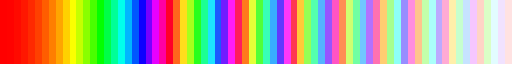

In [8]:
def get_colors ( num_colors ) :
    x = np.linspace ( 0.0 , 1.0 , num_colors )
    a = np.floor ( x * x * np.sqrt ( num_colors ) )
    v = 1.0 - a / ( np.max ( a ) + 1 )
    h = x * x * ( np.max ( a ) + 1 )
    h = h - np.floor ( h )
    hsv = np.ones ( [num_colors,3] )
    hsv [:,0] = h
    hsv [:,1] = v
    hsv [:,2] = 1.0
    rgb = matplotlib.colors.hsv_to_rgb ( hsv )
    rgba = np.ones ( [num_colors,4] )
    rgba [:,0:3] = rgb
    return rgba

my_colors = get_colors ( num_entities )
my_colormap = matplotlib.colors.ListedColormap ( my_colors )
my_colormap.set_under ( 'black' ) # guard rail to be sure that we use the right colors
my_colormap.set_over ( 'black' ) # guard rail to be sure that we use the right colors
my_colormap

### 2.4. Plot the performances in ROC, just for information.

You can plot the ROC plot. The ROC space is a well established standard to plot two-class classification performances as points, but it does not allow to vizualize the diversity of rankings at a glance. So, the ROC plot is not used at all to establish rankings in our work; we provide this code only for information. This step can be skipped if you do not need it.

In [9]:
from scipy.spatial import ConvexHull

""" 
This function draws a broken line corresponding to the supremum of 
all achievable performances and returns the list of indices of all 
the entities that are on this broken line, called the supremum line.
An entity will be part of the Entity Tile "Who's first?" if its 
performance is in this list.
"""
def plot_best_performances_in_roc ( fpr , tpr , style ) :
    n = (fpr+tpr).size
    min_fpr = np.min ( fpr )
    max_fpr = np.max ( fpr )
    min_tpr = np.min ( tpr )
    max_tpr = np.max ( tpr )
    fprs_ = np.append ( fpr , [1, 1, min_fpr] )
    tprs_ = np.append ( tpr , [max_tpr, 0, 0] )
    points = np.empty ( (n+3, 2) )
    points [:,0] = fprs_
    points [:,1] = tprs_
    hull = ConvexHull ( points )
    best_entities_idx = set ()
    for simplex in hull.simplices :
        for entity_idx in simplex :
            if entity_idx < n :
                best_entities_idx.add ( entity_idx )
        xs = points [simplex, 0]
        ys = points [simplex, 1]
        if np.any ( xs<1 ) and np.any ( ys>0 ) :
            plt.plot ( xs, ys, style )
    return best_entities_idx

""" 
This function draws a broken line corresponding to the infimum of 
all achievable performances and returns the list of indices of all 
the entities that are on this broken line, called the infimum line.
An entity will be part of the Entity Tile "Who's last?" if its 
performance is in this list.
"""
def plot_worst_performances_in_roc ( fpr , tpr , style ) :
    n = (fpr+tpr).size
    min_fpr = np.min ( fpr )
    max_fpr = np.max ( fpr )
    min_tpr = np.min ( tpr )
    max_tpr = np.max ( tpr )
    fprs_ = np.append ( fpr , [max_fpr, 0, 0] )
    tprs_ = np.append ( tpr , [1, 1, min_tpr] )
    points = np.empty ( (n+3, 2) )
    points [:,0] = fprs_
    points [:,1] = tprs_
    hull = ConvexHull ( points )
    worst_entities_idx = set ()
    for simplex in hull.simplices :
        for entity_idx in simplex :
            if entity_idx < n :
                worst_entities_idx.add ( entity_idx )
        xs = points [simplex, 0]
        ys = points [simplex, 1]
        if np.any ( xs>0 ) and np.any ( ys<1 ) :
            plt.plot ( xs, ys, style )
    return worst_entities_idx

Plotting the whole ROC space ...


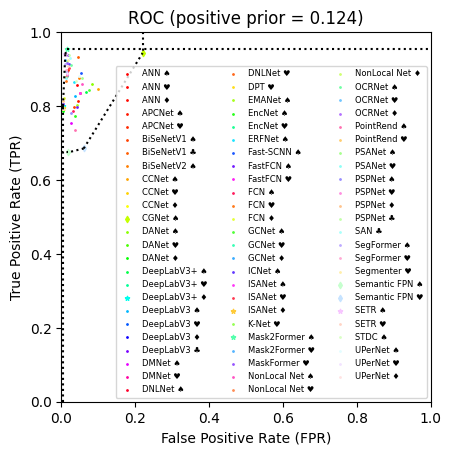

Plotting a zoom in the ROC space (v1) ...


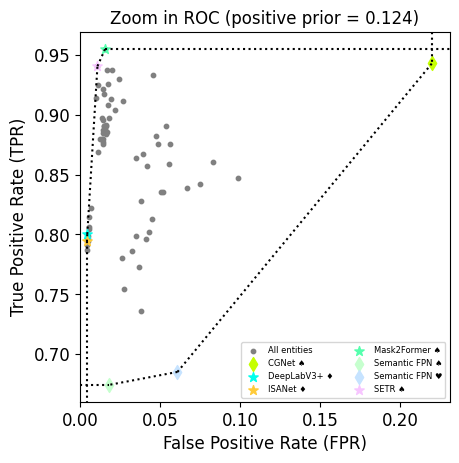

Plotting a zoom in the ROC space (v2) ...


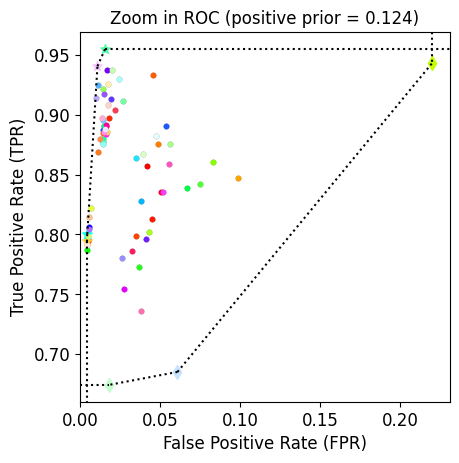

In [10]:
def get_filename_roc () :
    return os.path.join ( 'input', 'roc', 'roc.pdf' )

def get_filename_roc_zoom_1 () :
    return os.path.join ( 'input', 'roc', 'roc_zoom_v1.pdf' )

def get_filename_roc_zoom_2 () :
    return os.path.join ( 'input', 'roc', 'roc_zoom_v2.pdf' )

if cst_priors :
    
    fpr = 1 - tnr
    
    print ( 'Plotting the whole ROC space ...' )
    fig, ax = before_plotting_roc ()
    best_entities_idx = plot_best_performances_in_roc ( fpr , tpr , 'k:' )
    worst_entities_idx = plot_worst_performances_in_roc ( fpr , tpr , 'k:' )
    for e in range ( num_entities ) :
        entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
        if e in worst_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='d', label=entity_name, s=10 )
        elif e in best_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='*', label=entity_name, s=10 )
        else :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='o', label=entity_name, s=1 )
    ax.set_xlim ( 0.0 , 1.0 )
    ax.set_xlabel ( 'False Positive Rate (FPR)' )
    ax.set_ylim ( 0.0 , 1.0 )
    ax.set_ylabel ( 'True Positive Rate (TPR)' )
    ax.set_aspect ( 'equal' )
    ax.set_title ( 'ROC (positive prior = {:.3f})'.format (cst_prior_pos) )
    tiny = 6*fontsize_magnification_roc if fontsize_magnification_roc>0 else 6
    legend = ax.legend ( loc='lower right', ncol=3, fontsize=tiny )
    after_plotting_roc ( ax , get_filename_roc () )
    
    print ( 'Plotting a zoom in the ROC space (v1) ...' )
    fig, ax = before_plotting_roc ()
    best_entities_idx = plot_best_performances_in_roc ( fpr , tpr , 'k:' )
    worst_entities_idx = plot_worst_performances_in_roc ( fpr , tpr , 'k:' )
    plt.scatter ( fpr , tpr, color=(0.5,0.5,0.5), label='All entities', s=10 )
    for e in range ( num_entities ) :
        entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
        if e in worst_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='d', label=entity_name, s=50 )
        elif e in best_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='*', label=entity_name, s=50 )
    min_fpr = np.min ( fpr )
    max_fpr = np.max ( fpr )
    min_tpr = np.min ( tpr )
    max_tpr = np.max ( tpr )
    delta_fpr = max_fpr - min_fpr
    delta_tpr = max_tpr - min_tpr
    min_fpr = max ( 0 , min_fpr - delta_fpr / 20 )
    max_fpr = min ( 1 , max_fpr + delta_fpr / 20 )
    min_tpr = max ( 0 , min_tpr - delta_tpr / 20 )
    max_tpr = min ( 1 , max_tpr + delta_tpr / 20 )
    ax.set_xlim ( min_fpr , max_fpr )
    ax.set_xlabel ( 'False Positive Rate (FPR)' )
    ax.set_ylim ( min_tpr , max_tpr )
    ax.set_ylabel ( 'True Positive Rate (TPR)' )
    ax.set_box_aspect ( 1 ) # square
    ax.set_title ( 'Zoom in ROC (positive prior = {:.3f})'.format (cst_prior_pos) )
    tiny = 6*fontsize_magnification_roc if fontsize_magnification_roc>0 else 6
    ax.legend ( loc='lower right', ncol=2, fontsize=tiny )
    after_plotting_roc ( ax, get_filename_roc_zoom_1 () )
    
    print ( 'Plotting a zoom in the ROC space (v2) ...' )
    fig, ax = before_plotting_roc ()
    best_entities_idx = plot_best_performances_in_roc ( fpr , tpr , 'k:' )
    worst_entities_idx = plot_worst_performances_in_roc ( fpr , tpr , 'k:' )
    plt.scatter ( fpr , tpr, color=(0.5,0.5,0.5), label='All entities', s=10 )
    for e in range ( num_entities ) :
        entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
        if e in worst_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='d', label=entity_name, s=50 )
        elif e in best_entities_idx :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='*', label=entity_name, s=50 )
        else :
            plt.scatter ( fpr[e] , tpr[e], color=my_colors[e,:], marker='o', label=entity_name, s=10 )
    min_fpr = np.min ( fpr )
    max_fpr = np.max ( fpr )
    min_tpr = np.min ( tpr )
    max_tpr = np.max ( tpr )
    delta_fpr = max_fpr - min_fpr
    delta_tpr = max_tpr - min_tpr
    min_fpr = max ( 0 , min_fpr - delta_fpr / 20 )
    max_fpr = min ( 1 , max_fpr + delta_fpr / 20 )
    min_tpr = max ( 0 , min_tpr - delta_tpr / 20 )
    max_tpr = min ( 1 , max_tpr + delta_tpr / 20 )
    ax.set_xlim ( min_fpr , max_fpr )
    ax.set_xlabel ( 'False Positive Rate (FPR)' )
    ax.set_ylim ( min_tpr , max_tpr )
    ax.set_ylabel ( 'True Positive Rate (TPR)' )
    ax.set_box_aspect ( 1 ) # square
    ax.set_title ( 'Zoom in ROC (positive prior = {:.3f})'.format (cst_prior_pos) )
    after_plotting_roc ( ax, get_filename_roc_zoom_2 () )
    
else :
    print ( 'The ROC space is not plotted because of inequal priors.' )

### 2.5. Plot the performances as plots of the mass function, just for information.

In [11]:
def get_filename_perfs_ptn_ptp () :
    return os.path.join ( 'input', 'perfs', 'perfs_ptn_ptp.pdf' )

def get_filename_perfs_pfp_pfn () :
    return os.path.join ( 'input', 'perfs', 'perfs_pfp_pfn.pdf' )
    
print ( 'P({tp}) / P({tn}) :' )
print ( '    min: {:g}'.format(np.min ( proba_tp/proba_tn ) ) )
print ( '    max: {:g}'.format(np.max ( proba_tp/proba_tn ) ) )
print ( '    mean: {:g}'.format(np.mean ( proba_tp/proba_tn ) ) )
print ( '    std: {:g}'.format(np.std ( proba_tp/proba_tn ) ) )

fig, ax = before_plotting_perfs ()
# setup_font_size ( fontsize_magnification_.... )
if cst_priors :
    rect = plt.Rectangle((0, 0), cst_prior_neg, cst_prior_pos, facecolor="black", alpha=0.2)
    ax.add_patch ( rect )
    plt.plot ( [cst_prior_neg, cst_prior_neg], [0, 1], 'k--' )
    plt.text ( cst_prior_neg, 0.5, '$\\pi_-={:g}$'.format ( cst_prior_neg ), ha='right', va='center', rotation='vertical', fontsize=12 )
    plt.plot ( [0, 1], [cst_prior_pos, cst_prior_pos], 'k--' )
    plt.text ( 0.5, cst_prior_pos, '$\\pi_+={:g}$'.format ( cst_prior_pos ), ha='center', va='bottom', fontsize=12 )
else :
    rect = plt.Rectangle((0, 0), 1, 1, facecolor="black", alpha=0.2)
    ax.add_patch ( rect )
plt.plot ( [cst_prior_neg-cst_prior_pos,cst_prior_neg+cst_prior_pos], [cst_prior_pos-cst_prior_pos,cst_prior_pos+cst_prior_pos], 'k:' )
plt.text ( cst_prior_neg, cst_prior_pos, 'unbiased\n'.format ( cst_prior_pos ), ha='center', va='center', rotation=45, fontsize=12 )
for e in range ( num_entities ) :
    if e in worst_entities_idx :
        plt.scatter ( proba_tn[e] , proba_tp[e], color=my_colors[e,:], marker='d')#, label=entity_name, s=10 )
    elif e in best_entities_idx :
        plt.scatter ( proba_tn[e] , proba_tp[e], color=my_colors[e,:], marker='*')#, label=entity_name, s=10 )
    else :
        plt.scatter ( proba_tn[e] , proba_tp[e], color=my_colors[e,:], marker='o')#, label=entity_name, s=1 )
ax.set_xlim ( 0 , 1 )
ax.set_xlabel ( '$P({tn})$' )
ax.set_xticks ( np.linspace ( 0, 1, 6 ) )
ax.set_ylim ( 0, 1 )
ax.set_ylabel ( '$P({tp})$' )
ax.set_yticks ( np.linspace ( 0, 1, 6 ) )
ax.grid ( True )
ax.set_box_aspect ( 1 ) # square
after_plotting_perfs ( ax , get_filename_perfs_ptn_ptp() )

print ( 'P({fn}) / P({tp}) :' )
print ( '    min: {:g}'.format(np.min ( proba_fn/proba_fp ) ) )
print ( '    max: {:g}'.format(np.max ( proba_fn/proba_fp ) ) )
print ( '    mean: {:g}'.format(np.mean ( proba_fn/proba_fp ) ) )
print ( '    std: {:g}'.format(np.std ( proba_fn/proba_fp ) ) )

fig, ax = before_plotting_perfs ()
# setup_font_size ( fontsize_magnification_.... )
if cst_priors :
    rect = plt.Rectangle((0, 0), cst_prior_neg, cst_prior_pos, facecolor="black", alpha=0.2)
    ax.add_patch ( rect )
    plt.plot ( [cst_prior_neg, cst_prior_neg], [0, 1], 'k--' )
    plt.text ( cst_prior_neg, 0.5, '$\\pi_-={:g}$'.format ( cst_prior_neg ), ha='right', va='center', rotation='vertical', fontsize=12 )
    plt.plot ( [0, 1], [cst_prior_pos, cst_prior_pos], 'k--' )
    plt.text ( 0.5, cst_prior_pos, '$\\pi_+={:g}$'.format ( cst_prior_pos ), ha='center', va='bottom', fontsize=12 )
else :
    rect = plt.Rectangle((0, 0), 1, 1, facecolor="black", alpha=0.2)
    ax.add_patch ( rect )
plt.plot ( [0,1], [0,1], 'k:' )
plt.text ( 0.5, 0.5, 'unbiased\n'.format ( cst_prior_pos ), ha='center', va='center', rotation=45, fontsize=12 )
for e in range ( num_entities ) :
    if e in worst_entities_idx :
        plt.scatter ( proba_fp[e] , proba_fn[e], color=my_colors[e,:], marker='d')#, label=entity_name, s=10 )
    elif e in best_entities_idx :
        plt.scatter ( proba_fp[e] , proba_fn[e], color=my_colors[e,:], marker='*')#, label=entity_name, s=10 )
    else :
        plt.scatter ( proba_fp[e] , proba_fn[e], color=my_colors[e,:], marker='o')#, label=entity_name, s=1 )
ax.set_xlim ( 0 , 1 )
ax.set_xlabel ( '$P({fp})$' )
ax.set_xticks ( np.linspace ( 0, 1, 6 ) )
ax.set_ylim ( 0, 1 )
ax.set_ylabel ( '$P({fn})$' )
ax.set_yticks ( np.linspace ( 0, 1, 6 ) )
ax.grid ( True )
ax.set_box_aspect ( 1 ) # square
after_plotting_perfs ( ax , get_filename_perfs_pfp_pfn() )

P({tp}) / P({tn}) :
    min: 0.0974182
    max: 0.171528
    mean: 0.125238
    std: 0.0101392


KeyboardInterrupt: 

## 3. Implementation of algorithms for Tiles

We now provide original implementation of algorithms to compute elements that have been introduced in
    S. Piérard, A. Halin, A. Cioppa, A. Deliège, and M. Van Droogenbroeck.
    The Tile: A 2D map of ranking scores for two-class classification.
    arXiv, abs/2412.04309, 2024.

### 3.1. Reference curve for given priors

In [ ]:
def get_importances_for_given_prior_pos ( prior_pos , s ) :
    if math.isclose ( prior_pos, 0.5 ) :
        x, y = s, 1 - s
    else :
        if s <= 0.0 :
            return np.nan, np.nan, np.nan, np.nan
        if s >= 1.0 :
            return np.nan, np.nan, np.nan, np.nan
        prior_neg = 1 - prior_pos
        a, b, e = prior_neg*(1-s), prior_pos*s, prior_neg*(1-s)
        c, d, f = prior_pos*(1-s), prior_neg*s, prior_neg*s
        dx = e*d-b*f
        dy = a*f-e*c
        d = a*d-b*c
        assert not math.isclose ( d , 0.0, abs_tol=1e-8 )
        x, y = dx/d, dy/d
        #print ( d, x, y )
        #assert x >= -1e-8 and x <= 1+1e-8
        #assert y >= -1e-8 and y <= 1+1e-8
        if x < 0 or x > 1 :
            return np.nan, np.nan, np.nan, np.nan
        if y < 0 or y > 1 :
            return np.nan, np.nan, np.nan, np.nan
    importance_TN = 1 - x
    importance_FP = 1 - y
    importance_FN = y
    importance_TP = x
    return importance_TN, importance_FP, importance_FN, importance_TP

def plot_reference_curve_for_given_priors ( ax, prior_pos, color ) :
    all_s = np.linspace ( 0 , 1 , 1000 )
    all_x = np.empty ( all_s.shape )
    all_y = np.empty ( all_s.shape )
    for i, s in enumerate ( all_s ) :
        importance_TN, importance_FP, importance_FN, importance_TP = get_importances_for_given_prior_pos ( prior_pos , s )
        all_x [ i ] = importance_TP
        all_y [ i ] = importance_FN
    ax.plot ( all_x, all_y, '--', c=color )

    

### 3.2. The polygon algorithm 
A little bit of geometry to compute polygons (to be superimposed on the tile if we want so).

This algorithm allows you to find the polygon corresponding to an area where a classifier is the best or the worst. It consists in defining linear constraints and finding the contours of the polygon satisfying those constraints.
The polygon is first found for priors equal to $0.5$, and then transformed to correspond to the right priors.

In [ ]:
"""
Computes the intersection between the lines:
a1 x + b1 y + c1 = 0
a2 x + b2 y + c2 = 0
Returns (x,y) if there is a unique solution, else (None,None)
"""
def lines_intersection ( line1, line2 ) :
    a1, b1, c1, name1 = line1
    a2, b2, c2, name2 = line2
    dx = -c1*b2+b1*c2
    dy = -a1*c2+c1*a2
    d = a1*b2-b1*a2
    try :
        x, y = dx/d, dy/d
        return x, y
    except :
        return None, None

"""
Returns true if and only if the point (x,y) satisfies all the
linear inequalities a * x + b * y + c > 0
"""
def satisfies_all_inequalities ( x, y, * inequalities ) :
    for inequality in inequalities :
        a, b, c, name = inequality
        v = a * x + b * y + c
        if v < 0 and not math.isclose ( v , 0.0, abs_tol=1e-8 ) :
            return False
    return True

In [ ]:
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon

"""
Converts the representation of a polygon:
- from: the intersection of half planes given by inequalities a * x + b * y + c > 0
- to: a circular path between vertices, that is a matplotlib.patches.Polygon object.
The input polygon is assumed to be for a positive prior equal to 0.5.
The output polygon is transformed to correspond to a positive prior equal to prior_pos.
"""
def polygon_half_planes_to_vertices ( prior_pos , * inequalities ) :
    xs = list ()
    ys = list ()
    for idx1, inequality1 in enumerate ( inequalities ) :
        for idx2, inequality2 in enumerate ( inequalities ) :
            if idx2 != idx1 :
                x, y = lines_intersection ( inequality1, inequality2 )
                if x is not None :
                    if satisfies_all_inequalities ( x, y, * inequalities ) :
                        xs.append ( x )
                        ys.append ( y )
    xs = np.asarray ( xs )
    ys = np.asarray ( ys )
    points = np.asarray ( [xs, ys] ) .T
    try :
        hull = ConvexHull(points)
    except :
        return None
    if math.isclose ( prior_pos , 0.5 ) :
        points = points [ hull.vertices , : ]
        return Polygon ( points, fill=False )
    else :
        l = np.linspace ( 0 , 1 , 10000 )
        all_x = list ()
        all_y = list ()
        xs = points[hull.vertices,0]
        ys = points[hull.vertices,1]
        n = len(hull.vertices)
        for i in range(n) :
            x1, x2 = xs [ i ], xs [ (i+1)%n ]
            y1, y2 = ys [ i ], ys [ (i+1)%n ]
            x = x1 * (1-l) + x2 * l
            y = y1 * (1-l) + y2 * l
            x , y = adapt_a_b ( 0.5 , prior_pos , x , y )
            all_x.append ( x )
            all_y.append ( y )
        all_x = np.concatenate ( all_x )
        all_y = np.concatenate ( all_y )
        points = np.asarray ( [all_x, all_y] ) .T
        return Polygon ( points, fill=False )

In [ ]:
"""
Computes the area in the Tile where all performances, such that (TNR,TPR) is in the first iterable,
are better than or equivalent to all performances, such that (TNR,TPR) is in the second iterable.
Output: a matplotlib.patches.Polygon object.
"""
def better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2 , prior_pos ) :

    inequalities = list ()
    # Let's first restrict the area of interest to the Tile.
    inequalities.append ( [1, 0, 0, 'left border'] ) # a >= 0
    inequalities.append ( [-1, 0, 1, 'right border'] ) # a <= 1 <=> -a+1 >= 0
    inequalities.append ( [0, 1, 0, 'lower border'] ) # b >= 0
    inequalities.append ( [0, -1, 1, 'top border'] ) # b <= 1 <=> -b+1 >= 0
    # Now, we consider each pair of performances.
    for idx1, tnr_tpr_1 in enumerate(list_tnr_tpr_1) :
        for idx2, tnr_tpr_2 in enumerate(list_tnr_tpr_2) :
            tnr1, tpr1 = tnr_tpr_1
            tnr2, tpr2 = tnr_tpr_2
            fpr1, fnr1 = 1-tnr1, 1-tpr1
            fpr2, fnr2 = 1-tnr2, 1-tpr2
            # When the priors are both 0.5, perf1 >= perf2 is a zone of the tile
            # bounded by the following straight line.
            coef_a = fpr1 * fnr2 - fnr1 * fpr2
            coef_b = tpr1 * tnr2 - tnr1 * tpr2
            coef_c = tnr1 - tnr2
            inequalities.append ( [coef_a, coef_b, coef_c, 'P{} >= P{}'.format(idx1,idx2) ] )
    # Now, we take the correct priors into account.
    return polygon_half_planes_to_vertices ( prior_pos , * inequalities )

In [ ]:
"""
This function is intended to be used with any tile specific to a given entity.
It hatches two areas on a previously drawn Tile (ax is the axes object of matplotlib):
- one where the e-th entity is worse than the no-skill classifier predicting always the positive class (/// hatches)
- one where the e-th entity is worse than the no-skill classifier predicting always the negative class (\\\\\\ hatches)

This function uses the global variables tnr and tpr that are assumed to be lists giving the
true negative rate and true positive rate of each entity.
"""
def show_entity_worse_than_no_skill_on_tile ( ax, e , prior_pos , color ) :

    list_tnr_tpr_1 = list ()
    list_tnr_tpr_1.append ( [0,1] )
    list_tnr_tpr_2 = list ()
    list_tnr_tpr_2.append ( [tnr[e], tpr[e]] )
    polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
    if polygon is not None :
        area = ax.add_patch(polygon)
        area.set_hatch('///')
        area.set_edgecolor ( color )
    
    list_tnr_tpr_1 = list ()
    list_tnr_tpr_1.append ( [1,0] )
    list_tnr_tpr_2 = list ()
    list_tnr_tpr_2.append ( [tnr[e], tpr[e]] )
    polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
    if polygon is not None :
        area = ax.add_patch(polygon)
        area.set_hatch('\\\\\\')
        area.set_edgecolor ( color )

In [ ]:
"""
This function is intended to be used with the "State-of-the-Art Value Tile"
It hatches two areas on a previously drawn Tile (ax is the axes object of matplotlib):
- one where all entities are worse than the no-skill classifier predicting always the positive class (/// hatches)
- one where all entities are worse than the no-skill classifier predicting always the negative class (\\\\\\ hatches)

This function uses the global variables tnr and tpr that are assumed to be lists giving the
true negative rate and true positive rate of each entity.
"""
def show_comparison_state_of_the_art_no_skill ( ax, prior_pos, color ) :

    # all entities are worse than the classifier saying always "c+"

    list_tnr_tpr_1 = list ()
    list_tnr_tpr_1.append ( [0,1] )
    list_tnr_tpr_2 = list ()
    for e in range ( num_entities ) :
        list_tnr_tpr_2.append ( [tnr[e], tpr[e]] )
    polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
    if polygon is not None :
        area = ax.add_patch(polygon)
        area.set_hatch('///')
        area.set_edgecolor ( color )

    # all entities are worse than the classifier saying always "c-"
    
    list_tnr_tpr_1 = list ()
    list_tnr_tpr_1.append ( [1,0] )
    list_tnr_tpr_2 = list ()
    for e in range ( num_entities ) :
        list_tnr_tpr_2.append ( [tnr[e], tpr[e]] )
    polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
    if polygon is not None :
        area = ax.add_patch(polygon)
        area.set_hatch('\\\\\\')
        area.set_edgecolor ( color )

In [ ]:
"""
This function is intended to be used with the "Baseline Value Tile"
It hatches two areas on a previously drawn Tile (ax is the axes object of matplotlib):
- one where there exists an entity that is worse than all other entities (it belongs to the baseline Tile)
  and also worse than the no-skill classifier predicting always the positive class (/// hatches)
- one where there exists an entity that is worse than all other entities (it belongs to the baseline Tile)
  and also worse than the no-skill classifier predicting always the negative class (\\\\\\ hatches)

This function uses the global variables tnr and tpr that are assumed to be lists giving the
true negative rate and true positive rate of each entity.
"""
def show_comparison_baseline_no_skill ( ax, prior_pos, color ) :

    for e1 in range ( num_entities ) :

        list_tnr_tpr_1 = list ()
        list_tnr_tpr_1.append ( [0,1] )
        for e2 in range ( num_entities ) :
            if e2 != e1 :
                list_tnr_tpr_1.append ( [tnr[e2], tpr[e2]] )

        list_tnr_tpr_2 = list ()
        list_tnr_tpr_2.append ( [tnr[e1], tpr[e1]] )
        
        polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
        if polygon is not None :
            # print ( '(+) Showing polygon for entity', get_entity_pretty_name_stdout ( list_of_entities [ e1 ] ) )
            area = ax.add_patch(polygon)
            area.set_hatch('///')
            area.set_edgecolor ( color )
        else :
            pass # print ( '(+) Nothing to show for entity', get_entity_pretty_name_stdout ( list_of_entities [ e1 ] ) )

        list_tnr_tpr_1 = list ()
        list_tnr_tpr_1.append ( [1,0] )
        for e2 in range ( num_entities ) :
            if e2 != e1 :
                list_tnr_tpr_1.append ( [tnr[e2], tpr[e2]] )

        list_tnr_tpr_2 = list ()
        list_tnr_tpr_2.append ( [tnr[e1], tpr[e1]] )
        
        polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
        if polygon is not None :
            # print ( '(-) Showing polygon for entity', get_entity_pretty_name_stdout ( list_of_entities [ e1 ] ) )
            area = ax.add_patch(polygon)
            area.set_hatch('\\\\\\')
            area.set_edgecolor ( color )
        else :
            pass # print ( '(-) Nothing to show for entity', get_entity_pretty_name_stdout ( list_of_entities [ e1 ] ) )

In [ ]:
"""
This function draws the contour of all areas corresponding to entities ranked first.
"""
def show_all_who_is_first_areas ( ax, prior_pos, color ) :
    for e1 in range ( num_entities ) :
        list_tnr_tpr_1 = list ()
        list_tnr_tpr_1.append ( [tnr[e1], tpr[e1]] )
        list_tnr_tpr_2 = list ()
        for e2 in range ( num_entities ) :
            if e2 != e1 :
                list_tnr_tpr_2.append ( [tnr[e2], tpr[e2]] )
        polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
        if polygon is not None :
            area = ax.add_patch(polygon)
            area.set_edgecolor ( color )

In [ ]:
"""
This function draws the contour of all areas corresponding to entities ranked last.
"""
def show_all_who_is_last_areas ( ax, prior_pos, color ) :
    for e1 in range ( num_entities ) :
        list_tnr_tpr_1 = list ()
        for e2 in range ( num_entities ) :
            if e2 != e1 :
                list_tnr_tpr_1.append ( [tnr[e2], tpr[e2]] )
        list_tnr_tpr_2 = list ()
        list_tnr_tpr_2.append ( [tnr[e1], tpr[e1]] )
        polygon = better_or_equivalent_than ( list_tnr_tpr_1, list_tnr_tpr_2, prior_pos )
        if polygon is not None :
            area = ax.add_patch(polygon)
            area.set_edgecolor ( color )

## 4. Various uses of the Tile

Now begin the interesting things :-D

### 4.1. Value Tile: Using the tile to show the canonical ranking scores values for each entity

#### Computing

In [ ]:
vec_a = vec_b = np.linspace ( 0.5/tile_grid_size , 1-0.5/tile_grid_size , tile_grid_size )
a, b = np.meshgrid ( vec_a , vec_b , indexing='xy' )
I_tn = 1 - a
I_fp = 1 - b
I_fn = b
I_tp = a

all_tiles_of_canonical_ranking_scores_values = [ None for _ in list_of_entities ]
for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_stdout ( list_of_entities [ e ] )
    print ( 'Computing the Value Tile for the entity "{}" ...'.format ( entity_name ) )
    all_tiles_of_canonical_ranking_scores_values [ e ] = compute_ranking_score_value ( proba_tn [ e ] , proba_fp [ e ] , proba_fn [ e ] , proba_tp [ e ] , I_tn , I_fp , I_fn , I_tp )


#### Plotting

In [ ]:
def get_filename_tile_canonical_scores ( e ) :
    filename = 'value_tile_for_entity_{}.pdf'.format ( list_of_entities[e]['filename'] )
    return os.path.join ( 'results', 'value_tiles', filename )

def get_levels ( value_tile ) :
    max_val = np.max ( value_tile )
    min_val = np.min ( value_tile )
    if max_val - min_val < 0.01 :
        return np.linspace(0,1,1001)
    elif max_val - min_val < 0.02 :
        return np.linspace(0,1,501)
    elif max_val - min_val < 0.05 :
        return np.linspace(0,1,201)
    if max_val - min_val < 0.1 :
        return np.linspace(0,1,101)
    elif max_val - min_val < 0.2 :
        return np.linspace(0,1,51)
    elif max_val - min_val < 0.5 :
        return np.linspace(0,1,21)
    else :
        return np.linspace(0,1,11)        

for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
    print ( 'Plotting the Value Tile for the entity "{}" ...'.format ( entity_name ) )
    fig, ax = before_plotting_tile ()
    tile = all_tiles_of_canonical_ranking_scores_values [ e ]
    im = ax.imshow ( tile, extent=(0,1,0,1), origin='lower', interpolation='bilinear', cmap='gray', vmin=0.8, vmax=1.0 )
    if cst_priors :
        show_entity_worse_than_no_skill_on_tile ( ax, e , cst_prior_pos, 'hotpink' )
        if plot_reference_curve_for_given_priors_on_value_tiles :
            plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'palegreen' )
    if tile_draw_isovalue_curves :
        cs = ax.contour ( vec_a, vec_b, tile, levels=get_levels(tile), colors='cornflowerblue' )
        tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
        ax.clabel ( cs, inline=True, fontsize=tiny )
    ax.set_title ( '{}'.format ( entity_name ) )
    fig.colorbar ( im, ax=ax, label='Score Value' )
    filename = get_filename_tile_canonical_scores ( e )
    after_plotting_tile ( ax, filename )

### 4.2. Baseline Value Tile and State-of-the-Art Value Tile: Using the tile to show the 'Baseline' and 'State of the Art'

In [ ]:
def get_filename_tile_baseline () :
    return os.path.join ( 'results', 'overall', 'baseline_value_tile.pdf' )

def get_filename_tile_state_of_the_art () :
    return os.path.join ( 'results', 'overall', 'state_of_the_art_value_tile.pdf' )
    
    
# Compute the Baseline and State-of-the-Art Value Tiles

tile_baseline = np.full((tile_grid_size,tile_grid_size), np.inf)
tile_state_of_the_art = np.full((tile_grid_size,tile_grid_size), -np.inf)
for e in range ( num_entities ) :
    tile = all_tiles_of_canonical_ranking_scores_values [ e ]
    tile_baseline = np.minimum ( tile_baseline , tile )
    tile_state_of_the_art = np.maximum ( tile_state_of_the_art , tile )

fig, ax = before_plotting_tile ()
im = ax.imshow ( tile_baseline, extent=(0,1,0,1), origin='lower', interpolation='bilinear', cmap='gray', vmax=1.0 )
if cst_priors :
    show_all_who_is_last_areas ( ax, cst_prior_pos, 'w' )
    show_comparison_baseline_no_skill ( ax, cst_prior_pos, 'hotpink' )
    if plot_reference_curve_for_given_priors_on_baseline_tile :
        plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'palegreen' )
if tile_draw_isovalue_curves : 
    cs = ax.contour ( vec_a, vec_b, tile_baseline, levels=get_levels(tile_baseline), colors='cornflowerblue' )
    tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
    ax.clabel ( cs, inline=True, fontsize=tiny )
ax.set_title ( 'Baseline' )
fig.colorbar ( im, ax=ax, label='Score Value' )
after_plotting_tile ( ax , get_filename_tile_baseline () )

fig, ax = before_plotting_tile ()
im = ax.imshow ( tile_state_of_the_art, extent=(0,1,0,1), origin='lower', interpolation='bilinear', cmap='gray', vmax=1.0 )
if cst_priors :
    show_all_who_is_first_areas ( ax, cst_prior_pos, 'w' )
    show_comparison_state_of_the_art_no_skill ( ax, cst_prior_pos, 'hotpink' )
    if plot_reference_curve_for_given_priors_on_state_of_the_art_tile :
        plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'palegreen' )
if tile_draw_isovalue_curves : 
    cs = ax.contour ( vec_a, vec_b, tile_state_of_the_art, levels=get_levels(tile_state_of_the_art), colors='cornflowerblue' )
    tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
    ax.clabel ( cs, inline=True, fontsize=tiny )
ax.set_title ( 'State of the art' )
fig.colorbar ( im, ax=ax, label='Score Value' )
after_plotting_tile ( ax , get_filename_tile_state_of_the_art () )

### 4.3. No-Skill Tile and Relative-Skill Tile: Using the tile to show the 'No-Skill Values' and 'Relative Skill Values'

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

def get_clamped_colormap ( name , clamped_min_val , clamped_max_val ) :
    clamped_min_val = min ( max ( clamped_min_val , 0 ) , 1 )
    clamped_max_val = min ( max ( clamped_max_val , 0 ) , 1 )
    # print ( name , clamped_min_val , clamped_max_val )
    cmp = cm.get_cmap(name, 2048)
    N = cmp.N
    newcolors = cmp(np.linspace(0, 1, N))
    white = np.array([256/256, 256/256, 256/256, 1])
    newcolors[math.floor(clamped_min_val*(N-1)), :] = white
    newcolors[math.ceil(clamped_max_val*(N-1)):, :] = white
    newcmp = ListedColormap(newcolors)
    return newcmp

# crop line a x + b y + c = 0 with axis aligned bounding box [ x_min, x_max ] x [ y_min, y_max ]
# returns the end points of the segment
def crop_line ( a, b, c, x_min, x_max, y_min, y_max ) :
    
    points = list ()

    if not math.isclose ( b , 0, abs_tol=1e-8 ) :
        
        x = x_min
        y = ( - c - a * x ) / b
        if y_min <= y and y <= y_max :
            points.append ( [x,y] )
        
        x = x_max
        y = ( - c - a * x ) / b
        if y_min <= y and y <= y_max :
            points.append ( [x,y] )

    if not math.isclose ( a , 0, abs_tol=1e-8 ) :
        
        y = y_min
        x = ( - c - b * y ) / a
        if x_min <= x and x <= x_max :
            points.append ( [x,y] )
        
        y = y_max
        x = ( - c - b * y ) / a
        if x_min <= x and x <= x_max :
            points.append ( [x,y] )

    p1_optimal = None
    p2_optimal = None
    d2_optimal = -1.0
    for p1 in points :
        for p2 in points :
            x1, y1 = p1
            x2, y2 = p2
            dx, dy = x1 - x2, y1 - y2
            d2 = dx * dx + dy * dy
            if d2 > d2_optimal :
                p1_optimal = p1
                p2_optimal = p2
                d2_optimal = d2
    return p1_optimal, p2_optimal

def get_filename_tile_no_skill_values () :
    return os.path.join ( 'results', 'overall', 'no_skill_tile.pdf' )

def get_filename_tile_relative_skill_values () :
    return os.path.join ( 'results', 'overall', 'relative_skill_tile.pdf' )

if cst_priors :

    n = tile_grid_size
    a_vec = np.linspace ( 0.5/n , 1-0.5/n , n )
    b_vec = np.linspace ( 0.5/n , 1-0.5/n , n )
    a_grid, b_grid = np.meshgrid ( a_vec , b_vec , indexing='xy' )
    no_skill_tile = - np.ones ( [n,n] )
    
    importance_TP, importance_FN = a_grid, b_grid
    importance_FP, importance_TN = 1 - importance_FN, 1 - importance_TP
    
    def update ( tnr, tpr ) :
        ptn, pfp, pfn, ptp = tnr*cst_prior_neg, (1-tnr)*cst_prior_neg, (1-tpr)*cst_prior_pos, tpr*cst_prior_pos
        print ( 'Considering no-skill performance: {:.2f} {:.2f} {:.2f} {:.2f}'.format( ptn, pfp, pfn, ptp ) )
        v_ok = ptn * importance_TN + ptp * importance_TP
        v_ko = pfp * importance_FP + pfn * importance_FN
        v = v_ok / ( v_ok + v_ko )
        better = v > no_skill_tile
        no_skill_tile [ better ] = v [ better ]
    
    update ( 0, 1 )
    update ( 1, 0 )
    
    clamped_min_val = np.min(no_skill_tile)
    clamped_max_val = np.max(no_skill_tile)
    cmp = get_clamped_colormap ( 'gray', clamped_min_val, clamped_max_val )
    
    fig, ax = before_plotting_tile ()
    im = ax.imshow(no_skill_tile,extent=(0,1,0,1),origin='lower', interpolation='bilinear', cmap=cmp, vmin=0, vmax=1 ) # extent is (left, right, bottom, top)
    if tile_draw_isovalue_curves : 
        cs = ax.contour ( a_vec, b_vec, no_skill_tile, levels=np.linspace(0,0.75,16), colors='cornflowerblue' )
        cs = ax.contour ( a_vec, b_vec, no_skill_tile, levels=np.linspace(0.8,1,5), colors='cornflowerblue' )
        tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
        ax.clabel ( cs, inline=True, fontsize=tiny )
    if cst_priors :
        if plot_reference_curve_for_given_priors_on_no_skill_tile :
            if False : # a possible implementation ...
                tnr1, tpr1 = 0, 1
                tnr2, tpr2 = 1, 0
                fpr1, fnr1 = 1-tnr1, 1-tpr1
                fpr2, fnr2 = 1-tnr2, 1-tpr2
                coef_a = fpr1 * fnr2 - fnr1 * fpr2
                coef_b = tpr1 * tnr2 - tnr1 * tpr2
                coef_c = tnr1 - tnr2
                p1, p2 = crop_line ( coef_a, coef_b, coef_c, 0, 1, 0, 1 )
                if p1 is not None :
                    a1, b1 = p1
                    a2, b2 = p2
                    if math.isclose ( cst_prior_pos , 0.5 ) :
                        ax.plot ( [a1, a2], [b1, b2], '--', c='k' )
                    else :
                        l = np.linspace ( 0 , 1 , 10000 )
                        a = a1 * l + a2 * (1-l)
                        b = b1 * l + b2 * (1-l)
                        a , b = adapt_a_b ( 0.5 , cst_prior_pos , a , b )
                        ax.plot ( a, b, '--', c='k' )
            else : # another possible implementation ...
                plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'k' )
    #ax.set_title ( 'No-skill tile for prior pos = {:g}'.format(cst_prior_pos) )
    ax.set_title ( 'No skill' )
    #cbar = fig.colorbar(im, ax=ax, label='value achievable by no-skilled classifiers')
    cbar = fig.colorbar(im, ax=ax, label='achievable by no skill')
    after_plotting_tile ( ax , get_filename_tile_no_skill_values () )
    
    fig, ax = before_plotting_tile ()
    relative_skill_tile = (tile_state_of_the_art-no_skill_tile) / (1-no_skill_tile)
    im = ax.imshow(relative_skill_tile,extent=(0,1,0,1),origin='lower', interpolation='bilinear', cmap='gray', vmin=0, vmax=1 ) # extent is (left, right, bottom, top)
    if tile_draw_isovalue_curves :
        cs = ax.contour ( a_vec, b_vec, relative_skill_tile, levels=np.linspace(0,0.75,16), colors='cornflowerblue' )
        cs = ax.contour ( a_vec, b_vec, relative_skill_tile, levels=np.linspace(0.8,1,5), colors='cornflowerblue' )
        tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
        ax.clabel ( cs, inline=True, fontsize=tiny )
    if cst_priors :
        if plot_reference_curve_for_given_priors_on_relative_skill_tile :
            plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'k' )
    #ax.set_title ( 'Relative skill tile for prior pos = {:g}'.format(cst_prior_pos) )
    ax.set_title ( 'Relative skill' )
    cbar = fig.colorbar(im, ax=ax, label='achievable by the entities')
    after_plotting_tile ( ax , get_filename_tile_relative_skill_values () )



### 4.4. Ranking Tile: Using the tile to show the ranks for each entity

#### Computing

The code provided here is not optimized. It has a quadratic time complexity w.r.t. the number of entities. If you need a faster implementation, you could implement, for example, a quick sort for each point of the tile.

In [ ]:
all_tiles_of_ranks = [ None for _ in list_of_entities ]
for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_stdout ( list_of_entities [ e ] )
    print ( 'Computing the Ranking Tile for the entity "{}" ...'.format ( entity_name ) )
    tile_of_canonical_ranking_scores_values = all_tiles_of_canonical_ranking_scores_values [ e ]
    num_better_or_equivalent = np.zeros ( tile_of_canonical_ranking_scores_values.shape )
    num_better = np.zeros ( tile_of_canonical_ranking_scores_values.shape )
    for e_2 in range ( num_entities ) :
        tile_of_canonical_ranking_scores_value_2 = all_tiles_of_canonical_ranking_scores_values [ e_2 ]
        num_better_or_equivalent += tile_of_canonical_ranking_scores_value_2 >= tile_of_canonical_ranking_scores_values
        num_better += tile_of_canonical_ranking_scores_value_2 > tile_of_canonical_ranking_scores_values
    minimum_rank = num_better + 1
    maximum_rank = num_better_or_equivalent
    # The first axiom (cf. paper on the theoretical foundations of performance-based rankings) lets us choose
    # any rank between minimum_rank and maximum_rank.
    # Here we make an arbitraty choice in the case of equivalent performances.
    tile_of_ranks = ( minimum_rank + maximum_rank ) * 0.5
    all_tiles_of_ranks [ e ] = tile_of_ranks

# CONVENTION: in Ranking Tiles, the values are between 1 and num_entities.

#### Recommending

In [ ]:
def info_recommendation_1 ( str_begin_itemize, str_end_itemize, str_item, str_converter, get_entity_pretty_name ) :

    best_max_rank = num_entities + 1
    for e in range ( num_entities ) :
        tile_of_ranks = all_tiles_of_ranks [ e ]
        max_rank = np.max ( tile_of_ranks )
        best_max_rank = min ( best_max_rank , max_rank )

    print ( '' )
    print ( str_converter('The following entities mimimize the maximum rank:') )
    print ( str_begin_itemize )
    best_mean_rank = num_entities + 1
    for e in range ( num_entities ) :
        tile_of_ranks = all_tiles_of_ranks [ e ]
        max_rank = np.max ( tile_of_ranks )
        if max_rank == best_max_rank :
            mean_rank = np.mean ( tile_of_ranks )
            best_mean_rank = min ( best_mean_rank, mean_rank )
            entity_name = get_entity_pretty_name ( list_of_entities [ e ] )
            infos = '(max rank: {:g}, mean rank: {:g})'.format ( max_rank , mean_rank )
            print ( '{} {} {}'.format ( str_item , entity_name , str_converter(infos) ) )
    print ( str_end_itemize )

    print ( '' )
    print ( str_converter('Among them, the following entities have the lowest mean rank:') )
    print ( str_begin_itemize )
    for e in range ( num_entities ) :
        tile_of_ranks = all_tiles_of_ranks [ e ]
        max_rank = np.max ( tile_of_ranks )
        if max_rank == best_max_rank :
            mean_rank = np.mean ( tile_of_ranks )
            if mean_rank == best_mean_rank :
                entity_name = get_entity_pretty_name ( list_of_entities [ e ] )
                print ( '{}{}'.format ( str_item, entity_name ) )
    print ( str_end_itemize )

print ( '*************************************' )
print ( '*  One possible recommendation ...  *' )
print ( '*************************************' )

info_recommendation_1 ( '', '', '    - ', str, get_entity_pretty_name_stdout )

#### Plotting

In [ ]:
def get_filename_tile_ranks_for_entity ( e ) :
    filename = 'ranking_tile_for_entity_{}.pdf'.format(list_of_entities[e]['filename'])
    return os.path.join ( 'results', 'ranking_tiles', filename )

colormap_rank = plt.get_cmap ( 'rainbow', num_entities )

for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
    print ( 'Plotting the Ranking Tile for the entity "{}" ...'.format ( entity_name ) )
    tile_of_ranks = all_tiles_of_ranks [ e ]
    fig, ax = before_plotting_tile ()
    assert np.all ( tile_of_ranks >= 1 )
    assert np.all ( tile_of_ranks <= num_entities )
    im = ax.imshow ( tile_of_ranks, extent=(0,1,0,1), vmin=0.5, vmax=num_entities+0.5, origin='lower', interpolation='bilinear', cmap=colormap_rank)
    if cst_priors :
        show_entity_worse_than_no_skill_on_tile ( ax, e , cst_prior_pos, 'k' )
        if plot_reference_curve_for_given_priors_on_ranking_tiles :
            plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'w' )
    ax.set_title ( '{}'.format ( entity_name ) )
    min_rank = int(np.min(tile_of_ranks))
    max_rank = int(np.max(tile_of_ranks))
    fig.colorbar ( im, ax=ax, label='Rank from {} to {}'.format(min_rank,max_rank), ticks=[1, num_entities] )
    filename = get_filename_tile_ranks_for_entity ( e )
    after_plotting_tile ( ax, filename )

### 4.5. Entity Tile: Using the tile to show the entities for each rank

#### Computing

In [ ]:
all_tiles_of_entities = [ None for _ in list_of_entities ]
for r in range ( num_entities ) :
    rank = r + 1
    print ( 'Computing the Entity Tile for the rank {} ...'.format ( rank ) )
    tile_of_entities = np.empty ( [tile_grid_size,tile_grid_size] )
    tile_of_entities [ : ] = -1 #np.nan
    for e , tile_of_ranks in enumerate ( all_tiles_of_ranks ) :
        tile_of_entities [ tile_of_ranks == rank ] = e
    all_tiles_of_entities [ r ] = tile_of_entities

# CONVENTION: in Entity Tiles, the ids are between 0 and num_entities-1. The special
#             value -1 indicates that we have not chosen any entity at a given location.

#### Recommending

In [ ]:
def info_recommendation_2 ( str_begin_itemize, str_end_itemize, str_item, str_converter, get_entity_pretty_name ) :
    
    print ( '' )
    print ( str_converter('The following entities are ranked first:') )
    print ( str_begin_itemize )
    tile_of_entities = all_tiles_of_entities [ 0 ]
    selection = np.unique ( tile_of_entities )
    for e in selection :
        e = int(e)
        if e < 0 or e >= num_entities :
            continue
        entity_name = get_entity_pretty_name ( list_of_entities [ e ] )
        i, j = np.where ( tile_of_entities == e )
        coverage_pc = i.size / tile_of_entities.size * 100
        infos = '({:.2f}% of the tile)'.format ( coverage_pc )
        print ( '{}{} {}'.format ( str_item, entity_name , str_converter(infos) ) )
    print ( str_end_itemize )
    
print ( '*************************************' )
print ( '*  One possible recommendation ...  *' )
print ( '*************************************' )

info_recommendation_2 ( '', '', '    - ', str, get_entity_pretty_name_stdout )

#### Plotting

In [ ]:
def get_filename_tile_entities_for_rank ( rank ) :
    filename = 'entity_tile_for_rank_{}.pdf'.format(rank)
    return os.path.join ( 'results', 'entity_tiles', filename )

from scipy.ndimage import *

for r in range ( num_entities ) :
    rank = r + 1
    print ( 'Plotting the Entity Tile for the rank {} ...'.format ( rank ) )
    tile_of_entities = all_tiles_of_entities [ r ]
    fig, ax = before_plotting_tile ()
    assert np.all ( tile_of_entities >= -1 ) # The value -1 indicates "no entity"
    assert np.all ( tile_of_entities <= num_entities-1 )
    im = ax.imshow ( tile_of_entities, extent=(0,1,0,1), vmin=-0.5, vmax=num_entities-0.5, origin='lower', cmap=my_colormap, interpolation='none' )
    if cst_priors :
        if plot_reference_curve_for_given_priors_on_entity_tiles :
            plot_reference_curve_for_given_priors ( ax, cst_prior_pos, 'w' )
        if rank == 1 :
            show_comparison_state_of_the_art_no_skill ( ax, cst_prior_pos, 'k' )
        if rank == num_entities :
            show_comparison_baseline_no_skill ( ax, cst_prior_pos, 'k' )
    selection = np.unique ( tile_of_entities )
    for e in selection :
        e = int(e)
        if e < 0 or e >= num_entities :
            print ( 'WARNING: label {} found on the entity tile'.format ( e ) )
            continue
        entity_name = get_entity_pretty_name_plots ( list_of_entities [ e ] )
        i, j = np.where ( tile_of_entities == e )
        coverage_pc = i.size / tile_of_entities.size * 100
        print ( '   This entity is in the tile: [{}] {} ({:.2f}%)'.format ( e, entity_name , coverage_pc ) )
        # find each connected component and label its gravity center
        s = generate_binary_structure ( 2, 3 )
        labeled_array, num_connected_components = label ( tile_of_entities == e, structure=s )
        for c in range ( num_connected_components ) :
            i, j = np.where ( labeled_array == c+1 )
            if i.size / tile_of_entities.size >= 0.025 :
                mean_i = i.mean ()
                mean_j = j.mean ()
                if tile_of_entities [ int(np.round(mean_i)), int(np.round(mean_j)) ] == e :
                    i = ( mean_i + 0.5 ) / tile_of_entities.shape [ 0 ]
                    j = ( mean_j + 0.5 ) / tile_of_entities.shape [ 1 ]
                    tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
                    text = ax.text ( j, i, entity_name, ha="center", va="center", color="black", fontsize=tiny)
                else :
                    print ( 'WARNING: where should we place {}? The zone is not convex.'.format ( entity_name ) )
    
    #ax.set_title ( 'Who\'s ranked number {}?'.format ( rank ) )
    if rank == 1 :
        ax.set_title ( 'Who\'s first?' )
    elif rank == 2 :
        ax.set_title ( 'Who\'s second?' )
    elif rank == 3 :
        ax.set_title ( 'Who\'s third?' )
    elif rank == num_entities :
        ax.set_title ( 'Who\'s last?' )
    else :
        ax.set_title ( 'Who\'s {}th?'.format ( rank ) )
    
    filename = get_filename_tile_entities_for_rank ( rank )
    after_plotting_tile ( ax, filename )


### 4.6. Correlation Tile: Using the tile to show the rank and linear correlations with the mean-IoU

#### Computing

This is the slowest part of the code.
- On my laptop, it takes about 15 minutes to compute the correlation tile for Person's $r$ for 2001x2001 Tiles;
- On my laptop, it takes about 19 minutes to compute the correlation tile for Spearman's $\rho$ for 2001x2001 Tiles;
- On my laptop, it takes about  7 minutes to compute the correlation tile for Kendall's $\tau$ for 2001x2001 Tiles.

In [ ]:
import scipy.stats

def compute_correlation_tile ( list_score_values , scipy_correlation_fct ) :
    tile_correlation = np.empty ( [tile_grid_size,tile_grid_size] )
    tiles_of_canonical_ranking_scores_values = [ tile for tile, value in zip ( all_tiles_of_canonical_ranking_scores_values , list_score_values ) if value is not None ]
    x = np.array ( [ value for value in list_score_values if value is not None ] )
    for i in tqdm.tqdm(range ( tile_grid_size )) :
        for j in range ( tile_grid_size ) :
            y = np.array ( [ tile[i,j] for tile in tiles_of_canonical_ranking_scores_values ] )
            tile_correlation[i,j] = scipy_correlation_fct(x, y).correlation
    return tile_correlation

list_score_values = [ d [ 'macro_averaged_IoU' ] for d in list_of_entities ]
tile_ranking_scores_macro_iou_pearson_r = compute_correlation_tile ( list_score_values , scipy.stats.pearsonr )
tile_ranking_scores_macro_iou_spearman_rho = compute_correlation_tile ( list_score_values , scipy.stats.spearmanr )
tile_ranking_scores_macro_iou_kendall_tau = compute_correlation_tile ( list_score_values , scipy.stats.kendalltau )

#### Recommending

In [ ]:
def info_recommendation_3 ( tile_ranking_scores_macro_iou, symbol, str_begin_itemize, str_end_itemize, str_item, str_converter, get_entity_pretty_name ) :

    threshold_rho = 0.85    
    tile_of_entities = all_tiles_of_entities [ 0 ]
    print ( str_begin_itemize )
    threshold_ok = False
    for e in range ( num_entities ) :
        select_correl = tile_ranking_scores_macro_iou >= threshold_rho
        select_entity = tile_of_entities == e
        den = np.sum ( select_correl )
        num = np.sum ( select_correl * select_entity )
        if num > 0 :
            entity_name = get_entity_pretty_name ( list_of_entities [ e ] )
            infos = 'In {:.1f}% of the zone where {}≥{} in the tile, the best is'.format ( num/den*100 , symbol, threshold_rho )
            print ( '{}{} {}'.format ( str_item, str_converter(infos) , entity_name ))
            threshold_ok = True
    if not threshold_ok :
        infos = 'There is no zone where {}≥{} in the tile. Maybe do you want to change the threshold?'.format ( symbol, threshold_rho )
        print ( '{}{}'.format ( str_item, str_converter(infos) ))
    print ( str_end_itemize )

print ( '*************************************' )
print ( '*  One possible recommendation ...  *' )
print ( '*************************************' )

info_recommendation_3 ( tile_ranking_scores_macro_iou_pearson_r, 'r', '', '', '    - ', str, get_entity_pretty_name_stdout )

print ( '*************************************' )
print ( '*  One possible recommendation ...  *' )
print ( '*************************************' )

info_recommendation_3 ( tile_ranking_scores_macro_iou_spearman_rho, 'ρ', '', '', '    - ', str, get_entity_pretty_name_stdout )

print ( '*************************************' )
print ( '*  One possible recommendation ...  *' )
print ( '*************************************' )

info_recommendation_3 ( tile_ranking_scores_macro_iou_kendall_tau, '𝜏', '', '', '    - ', str, get_entity_pretty_name_stdout )


#### Plotting

In [ ]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

def get_clamped_colormap ( name , min_val , max_val, clamped_min_val , clamped_max_val ) :
    
    clamped_min_val = min ( max ( clamped_min_val , min_val ) , max_val )
    clamped_max_val = min ( max ( clamped_max_val , min_val ) , max_val )

    clamped_min_val = ( clamped_min_val - min_val ) / ( max_val - min_val )
    clamped_max_val = ( clamped_max_val - min_val ) / ( max_val - min_val )
    cmp = plt.get_cmap(name, 2048)
    N = cmp.N
    newcolors = cmp(np.linspace(0, 1, N))
    white = np.array([256/256, 256/256, 256/256, 1])
    min_idx=max(math.floor(clamped_min_val*N)-1,0)
    max_idx=min(math.ceil(clamped_max_val*N)+1,N)
    newcolors[:min_idx, :] = white
    newcolors[max_idx:, :] = white
    newcmp = ListedColormap(newcolors)
    return newcmp

In [ ]:
import matplotlib.colors as mcolors

def get_clamped_colormap_for_correlations ( clamped_min_val , clamped_max_val ) :
    N = 2048
    colors1 = get_clamped_colormap ( 'gist_rainbow_r' , -1 , 0, clamped_min_val , clamped_max_val )
    colors1 = 0.5 + colors1(np.linspace(0, 1, N)) *0.5
    colors2 = get_clamped_colormap ( 'gist_rainbow' , 0 , 1, clamped_min_val , clamped_max_val )
    colors2 = colors2(np.linspace(0, 1, N))
    colors = np.vstack((colors1, colors2))
    cmap = mcolors.LinearSegmentedColormap.from_list('correlation', colors, N=2*N)
    cmap.set_under ( 'white' )
    cmap.set_over ( 'white' )
    cmap.set_bad ( 'black' )
    return cmap

In [ ]:
get_clamped_colormap_for_correlations ( -1, 1 )

In [ ]:
def plot_correlation_tile ( tile_correlation, colormap_label, filename, threshold = 0.85 ) :

    fig, ax = before_plotting_tile ()
    clamped_min_val = np.min(tile_correlation)
    clamped_max_val = np.max(tile_correlation)
    cmap = get_clamped_colormap_for_correlations ( clamped_min_val, clamped_max_val )
    im = ax.imshow ( tile_correlation, extent=(0,1,0,1), origin='lower', interpolation='bilinear', cmap=cmap, vmin=-1, vmax=1 )
    cs = ax.contour ( a_vec, b_vec, tile_correlation, [threshold], colors='w' )
    tiny = 6*fontsize_magnification_tile if fontsize_magnification_tile>0 else 6
    ax.clabel ( cs, inline=True, fontsize=tiny )
    ax.set_title ( 'Correlation with macro-IoU' )
    cbar = fig.colorbar ( im, ax=ax, label=colormap_label )
    if clamped_min_val <= threshold and threshold <= clamped_max_val :
        cbar.ax.plot ( [0, 1], [threshold, threshold] , 'w-' )
    after_plotting_tile ( ax, filename )

In [ ]:
def get_filename_tile_correlation_macro_iou_pearson_r () :
    return os.path.join ( 'results', 'correlation_tiles_macro_iou', 'correlation_tile_pearson_r.pdf' )

tile_correlation = tile_ranking_scores_macro_iou_pearson_r
colormap_label = 'Pearson\'s $r$'
filename = get_filename_tile_correlation_macro_iou_pearson_r ()
plot_correlation_tile ( tile_correlation, colormap_label, filename )

In [ ]:
def get_filename_tile_correlation_macro_iou_spearman_rho () :
    return os.path.join ( 'results', 'correlation_tiles_macro_iou', 'correlation_tile_spearman_rho.pdf' )

tile_correlation = tile_ranking_scores_macro_iou_spearman_rho
colormap_label = 'Spearman\'s $\\rho$'
filename = get_filename_tile_correlation_macro_iou_spearman_rho ()
plot_correlation_tile ( tile_correlation, colormap_label, filename )

In [ ]:
def get_filename_tile_correlation_macro_iou_kendall_tau () :
    return os.path.join ( 'results', 'correlation_tiles_macro_iou', 'correlation_tile_kendall_tau.pdf' )

tile_correlation = tile_ranking_scores_macro_iou_kendall_tau
colormap_label = 'Kendall\'s $\\tau$'
filename = get_filename_tile_correlation_macro_iou_kendall_tau ()
plot_correlation_tile ( tile_correlation, colormap_label, filename )

## 5. Generating the LaTeX report with all the figures

In [ ]:
%%capture latex_report

rel_path_from_latex_to_plots = os.path.relpath ( plots_output_directory, os.path.dirname(output_report_latex_file) )

# Start document

print ( r"\documentclass[a4paper,american]{article}" )
print ( "" )

# Preamble

print ( r"\usepackage[T1]{fontenc}" )
print ( r"\usepackage[latin9]{inputenc}" )
print ( r"\usepackage{longtable}" )
print ( r"\usepackage{graphicx}" )
print ( r"\usepackage{a4wide}" )
print ( r"\usepackage{babel}" )
print ( r"\usepackage{pifont}" )
print ( r"\usepackage{hyperref}" )
print ( "" )

# Begin document

print ( r"\begin{document}" )
print ( "" )

print ( r"\global\long\def\aPerformance{P}%" )
print ( r"\global\long\def\sampleTN{tn}%" )
print ( r"\global\long\def\sampleFP{fp}%" )
print ( r"\global\long\def\sampleFN{fn}%" )
print ( r"\global\long\def\sampleTP{tp}%" )
print ( r"\global\long\def\eventTN{\{\sampleTN\}}%" )
print ( r"\global\long\def\eventFP{\{\sampleFP\}}%" )
print ( r"\global\long\def\eventFN{\{\sampleFN\}}%" )
print ( r"\global\long\def\eventTP{\{\sampleTP\}}%" )
print ( "" )

# Title

now = datetime.datetime.now ()
now = now.strftime ( "%B %d, %Y at %H:%M:%S" )

print ( r"\title{Performance-based analysis and ranking of", num_entities, "entities}" )
print ( r"\author{" )
print ( r"    Report generated by the code provided with the paper entitled\\" )
print ( r"    \emph{A Hitchhiker's Guide to Understanding Performances of Two-Class Classifiers}" )
print ( r"}" )
print ( r"\date{Analyzis performed on ", now, "}", sep='' )
print ( r"\maketitle" )
print ( "" )
print ( r"\tableofcontents{}" )
print ( "" )

# Infos in comments

for l in str(info_performances).splitlines () :
    print ( "%", l )
print ( "" )

# Abstract

print ( r"\begin{abstract}" )
print ( r"This report has been automatically generated by the code provided with the paper entitled " )
print ( r"\emph{A Hitchhiker's Guide to Understanding Performances of Two-Class Classifiers}~\cite{Halin2024AHitchhikers-arxiv}." )
print ( r"It presents a performance anlysis and a performance-based ranking that makes use of Tiles~\cite{Pierard2024TheTile-arxiv}," )
print ( r"a graphical tool based on the performance-based ranking theory developed in~\cite{Pierard2025Foundations}." )
print ( r"\end{abstract}" )

# Section 1

print ( "" )
print ( r"\section{The performances of the two-class classification entities}" )
print ( "" )

# Section 1.1

print ( "" )
print ( r"\subsection{Performances given as a table of elementary probabilities}" )
print ( "" )
#print ( unicode_to_latex(str(info_performances)) )
print ( r"\begin{longtable}[c]{|l|c|c|c|c|}" )
print ( r"\hline " )
print ( r"entity & $\aPerformance(\eventTN)$ & $\aPerformance(\eventFP)$ & $\aPerformance(\eventFN)$ & $\aPerformance(\eventTP)$\tabularnewline" )
print ( r"\hline " )
print ( r"\hline " )
for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_latex ( list_of_entities [ e ] )
    ptn = '{:.4f}'.format ( proba_tn [ e ] )
    pfp = '{:.4f}'.format ( proba_fp [ e ] )
    pfn = '{:.4f}'.format ( proba_fn [ e ] )
    ptp = '{:.4f}'.format ( proba_tp [ e ] )
    print ( entity_name, "&", ptn, "&", pfp, "&", pfn, "&", ptp, r"\tabularnewline" )
print ( r"\hline " )
print ( r"\end{longtable}" )

# Section 1.2

print ( "" )
print ( r"\subsection{Performances given as a table of ranking score values}" )
print ( "" )
score_1_values = accuracy
score_2_values = tnr
score_3_values = tpr
score_4_values = npv
score_5_values = ppv
score_6_values = j_neg
score_7_values = j_pos
score_8_values = f1
def val_2_rank ( values ) :
    def val_2_rank_aux ( values, val_ref ) :
        num_better = np.sum ( [ 1 if v > val_ref else 0 for v in values ] )
        num_better_or_equivalent = np.sum ( [ 1 if v >= val_ref else 0 for v in values ] )
        minimum_rank = num_better + 1
        maximum_rank = num_better_or_equivalent
        # The first axiom (cf. paper on the theoretical foundations of performance-based rankings) lets us choose
        # any rank between minimum_rank and maximum_rank.
        # Here we make an arbitraty choice in the case of equivalent performances.
        return ( minimum_rank + maximum_rank ) * 0.5
    return [ val_2_rank_aux ( values, val_ref ) for val_ref in values ]
score_1_ranks = val_2_rank ( score_1_values )
score_2_ranks = val_2_rank ( score_2_values )
score_3_ranks = val_2_rank ( score_3_values )
score_4_ranks = val_2_rank ( score_4_values )
score_5_ranks = val_2_rank ( score_5_values )
score_6_ranks = val_2_rank ( score_6_values )
score_7_ranks = val_2_rank ( score_7_values )
score_8_ranks = val_2_rank ( score_8_values )
print ( r"{\tiny" )
print ( r"\begin{longtable}[c]{|l|lr|lr|lr|lr|lr|lr|lr|lr|}" )
print ( r"\hline " )
print ( r"entity & $A$ & & $TNR$ & & $TPR$ & & $NPV$ & & $PPV$ & & $J_-$ & & $J_+$ & & $F_1$ & \tabularnewline" )
print ( r"\hline " )
print ( r"\hline " )
for e in range ( num_entities ) :
    entity_name = get_entity_pretty_name_latex ( list_of_entities [ e ] )
    s1 = "& {:.4f} & ({:g})".format ( score_1_values[e], score_1_ranks[e] )
    s2 = "& {:.4f} & ({:g})".format ( score_2_values[e], score_2_ranks[e] )
    s3 = "& {:.4f} & ({:g})".format ( score_3_values[e], score_3_ranks[e] )
    s4 = "& {:.4f} & ({:g})".format ( score_4_values[e], score_4_ranks[e] )
    s5 = "& {:.4f} & ({:g})".format ( score_5_values[e], score_5_ranks[e] )
    s6 = "& {:.4f} & ({:g})".format ( score_6_values[e], score_6_ranks[e] )
    s7 = "& {:.4f} & ({:g})".format ( score_7_values[e], score_7_ranks[e] )
    s8 = "& {:.4f} & ({:g})".format ( score_8_values[e], score_8_ranks[e] )
    print ( entity_name, s1, s2, s3, s4, s5, s6, s7, s8, r"\tabularnewline" )
print ( r"\hline " )
print ( r"\end{longtable}" )
print ( r"}" )

# Section 1.3

print ( "" )
print ( r"\subsection{Performances shown as $\aPerformance(\eventTP)$ vs. $\aPerformance(\eventTN)$ and $\aPerformance(\eventFN)$ vs. $\aPerformance(\eventFP)$ plots}" )
print ( "" )
print ( r"\begin{center}" )
filename = get_filename_perfs_ptn_ptp ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.8]{", path, "}", sep='' )
filename = get_filename_perfs_pfp_pfn ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.8]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"" )

# Section 1.4

print ( "" )
print ( r"\subsection{Performances shown in the ROC space}" )
print ( "" )
print ( r"\begin{center}" )
filename = get_filename_roc ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.8]{", path, "}", sep='' )
filename = get_filename_roc_zoom_1 ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.8]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"" )

# Section 2

print ( "" )
print ( r"\section{Results (Tiles)}" )
print ( "" )

# Section 2.1

print ( r"\subsection{Value Tile}" )
print ( r"Using the tile to show the canonical ranking scores values for each entity." )
print ( r"\begin{center}" )
for e in range ( num_entities ) :
    filename = get_filename_tile_canonical_scores ( e )
    path = os.path.join ( rel_path_from_latex_to_plots, filename )
    print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"" )

# Section 2.2

print ( r"\subsection{Baseline Value Tile and State-of-the-Art Value Tile}" )
print ( r"Using the tile to show the 'Baseline' and 'State of the Art'." )
print ( r"\begin{center}" )
filename = get_filename_tile_baseline ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
filename = get_filename_tile_state_of_the_art ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"" )

# Section 2.3

if cst_priors :
    print ( r"\subsection{No-Skill Tile and Relative-Skill Tile}" )
    print ( r"Using the tile to show the no-skill values and the relative skill values." )
    print ( r"\begin{center}" )
    filename = get_filename_tile_no_skill_values ()
    path = os.path.join ( rel_path_from_latex_to_plots, filename )
    print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
    filename = get_filename_tile_relative_skill_values ()
    path = os.path.join ( rel_path_from_latex_to_plots, filename )
    print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
    print ( r"\par\end{center}" )
    print ( r"" )

# Section 2.4

print ( r"\subsection{Ranking Tile}" )
print ( r"Using the tile to show the ranks for each entity." )
print ( r"\begin{center}" )
for e in range ( num_entities ) :
    filename = get_filename_tile_ranks_for_entity ( e )
    path = os.path.join ( rel_path_from_latex_to_plots, filename )
    print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"\paragraph{Analysis.}" )
info_recommendation_1 ( r'\begin{itemize}', r'\end{itemize}', '    \item ', unicode_to_latex, get_entity_pretty_name_latex )
print ( r"" )

# Section 2.5

print ( r"\subsection{Entity Tile}" )
print ( r"Using the tile to show the entities for each rank." )
print ( r"\begin{center}" )
for r in range ( num_entities ) :
    rank = r + 1
    filename = get_filename_tile_entities_for_rank ( rank )
    path = os.path.join ( rel_path_from_latex_to_plots, filename )
    print ( r"\includegraphics[scale=0.4]{", path, "}", sep='' )
print ( r"\par\end{center}" )
print ( r"\paragraph{Analysis.}" )
info_recommendation_2 ( r'\begin{itemize}', r'\end{itemize}', '    \item ', unicode_to_latex, get_entity_pretty_name_latex )
print ( r"" )

# Section 3.6

print ( r"\subsection{Correlation Tile}" )
print ( r"Using the tile to show the rank and linear correlations with the mean-IoU." )

print ( r"\begin{center}" )
filename = get_filename_tile_correlation_macro_iou_pearson_r ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.35]{", path, "}", sep='' )
filename = get_filename_tile_correlation_macro_iou_spearman_rho ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.35]{", path, "}", sep='' )
filename = get_filename_tile_correlation_macro_iou_kendall_tau ()
path = os.path.join ( rel_path_from_latex_to_plots, filename )
print ( r"\includegraphics[scale=0.35]{", path, "}", sep='' )
print ( r"\par\end{center}" )

print ( r"\paragraph{Analysis for the linear correlation with Pearson's $r$.}" )
info_recommendation_3 ( tile_ranking_scores_macro_iou_pearson_r, '$r$', r'\begin{itemize}', r'\end{itemize}', '    \item ', unicode_to_latex, get_entity_pretty_name_latex )
print ( r"" )

print ( r"\paragraph{Analysis for the rank correlation with Spearman's $\rho$.}" )
info_recommendation_3 ( tile_ranking_scores_macro_iou_spearman_rho, r'$\rho$', r'\begin{itemize}', r'\end{itemize}', '    \item ', unicode_to_latex, get_entity_pretty_name_latex )
print ( r"" )

print ( r"\paragraph{Analysis for the rank correlation with Kendall's $\tau$.}" )
info_recommendation_3 ( tile_ranking_scores_macro_iou_kendall_tau, r'$\tau$', r'\begin{itemize}', r'\end{itemize}', '    \item ', unicode_to_latex, get_entity_pretty_name_latex )
print ( r"" )

# Bibliography

print ( r"\begin{thebibliography}{3}" )
print ( r"" )
print ( r"\bibitem{Halin2024AHitchhikers-arxiv}" )
print ( r"Ana{\"\i}s Halin, S{\'e}bastien Pi{\'e}rard, Anthony Cioppa, and Marc Van~Droogenbroeck." )
print ( r"\newblock A hitchhiker's guide to understanding performances of two-class classifiers." )
print ( r"\newblock \emph{arXiv}, abs/2412.04377, 2024." )
print ( r"" )
print ( r"\bibitem{Pierard2024TheTile-arxiv}" )
print ( r"S{\'e}bastien Pi{\'e}rard, Ana{\"\i}s Halin, Anthony Cioppa, Adrien Deli{\`e}ge, and Marc Van~Droogenbroeck." )
print ( r"\newblock The {Tile}: A {2D} map of ranking scores for two-class classification." )
print ( r"\newblock \emph{arXiv}, abs/2412.04309, 2024." )
print ( r"" )
print ( r"\bibitem{Pierard2025Foundations}" )
print ( r"S{\'e}bastien Pi{\'e}rard, Ana{\"\i}s Halin, Anthony Cioppa, Adrien Deli{\`e}ge, and Marc Van~Droogenbroeck." )
print ( r"\newblock Foundations of the theory of performance-based ranking." )
print ( r"\newblock In \emph{IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)}, Nashville, TN, USA, 2025." )
print ( r"" )
print ( r"\end{thebibliography}" )

# End document

print ( r"\end{document}" )


In [ ]:
print ( latex_report )
with open ( output_report_latex_file, 'w' ) as f :
    f.write ( str(latex_report) )